<a href="https://colab.research.google.com/github/Adeeba04/nyc-taxi-fare-analysis/blob/main/NYC_Taxi_Fare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

# Prompt the file upload dialog
uploaded = files.upload()


Saving Taxi-data.csv to Taxi-data.csv


In [11]:
#Import standard libraries and load dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (update filename/path if needed)
t_data= pd.read_csv('Taxi-data.csv')

# Verify dimensions
print("Dataset Shape:", t_data.shape)
t_data.head(10)

Dataset Shape: (22699, 18)


,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80
5,23345809,2,03/25/2017 8:34:11 PM,03/25/2017 8:42:11 PM,6,2.30,1,N,161,236,1,9.0,0.5,0.5,2.06,0.0,0.3,12.36
6,37660487,2,05/03/2017 7:04:09 PM,05/03/2017 8:03:47 PM,1,12.83,1,N,79,241,1,47.5,1.0,0.5,9.86,0.0,0.3,59.16
7,69059411,2,08/15/2017 5:41:06 PM,08/15/2017 6:03:05 PM,1,2.98,1,N,237,114,1,16.0,1.0,0.5,1.78,0.0,0.3,19.58
8,8433159,2,02/04/2017 4:17:07 PM,02/04/2017 4:29:14 PM,1,1.20,1,N,234,249,2,9.0,0.0,0.5,0.00,0.0,0.3,9.80
9,95294817,1,11/10/2017 3:20:29 PM,11/10/2017 3:40:55 PM,1,1.60,1,N,239,237,1,13.0,0.0,0.5,2.75,0.0,0.3,16.55


In [12]:
t_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             22699 non-null  int64  
 1   VendorID               22699 non-null  int64  
 2   tpep_pickup_datetime   22699 non-null  object 
 3   tpep_dropoff_datetime  22699 non-null  object 
 4   passenger_count        22699 non-null  int64  
 5   trip_distance          22699 non-null  float64
 6   RatecodeID             22699 non-null  int64  
 7   store_and_fwd_flag     22699 non-null  object 
 8   PULocationID           22699 non-null  int64  
 9   DOLocationID           22699 non-null  int64  
 10  payment_type           22699 non-null  int64  
 11  fare_amount            22699 non-null  float64
 12  extra                  22699 non-null  float64
 13  mta_tax                22699 non-null  float64
 14  tip_amount             22699 non-null  float64
 15  to

In [13]:
t_data.describe()

,Unnamed: 0,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,2.269900e+04,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000
mean,5.675849e+07,1.556236,1.642319,2.913313,1.043394,162.412353,161.527997,1.336887,13.026629,0.333275,0.497445,1.835781,0.312542,0.299551,16.310502
std,3.274493e+07,0.496838,1.285231,3.653171,0.708391,66.633373,70.139691,0.496211,13.243791,0.463097,0.039465,2.800626,1.399212,0.015673,16.097295
min,1.212700e+04,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-120.000000,-1.000000,-0.500000,0.000000,0.000000,-0.300000,-120.300000
25%,2.852056e+07,1.000000,1.000000,0.990000,1.000000,114.000000,112.000000,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.750000
50%,5.673150e+07,2.000000,1.000000,1.610000,1.000000,162.000000,162.000000,1.000000,9.500000,0.000000,0.500000,1.350000,0.000000,0.300000,11.800000
75%,8.537452e+07,2.000000,2.000000,3.060000,1.000000,233.000000,233.000000,2.000000,14.500000,0.500000,0.500000,2.450000,0.000000,0.300000,17.800000
max,1.134863e+08,2.000000,6.000000,33.960000,99.000000,265.000000,265.000000,4.000000,999.990000,4.500000,0.500000,200.000000,19.100000,0.300000,1200.290000


In [14]:
# Sort by trip_distance descending (maximum to minimum)
df_sort_distance = t_data.sort_values(by='trip_distance', ascending=False)
df_sort_distance[['trip_distance', 'fare_amount', 'total_amount', 'passenger_count', 'RatecodeID']].head(10)

,trip_distance,fare_amount,total_amount,passenger_count,RatecodeID
9280,33.96,150.00,150.30,2,5
13861,33.92,200.01,258.21,1,5
6064,32.72,107.00,179.06,1,3
10291,31.95,131.00,131.80,1,4
29,30.83,80.00,111.38,1,1
18130,30.50,90.50,119.31,1,1
5792,30.33,52.00,73.20,1,2
15350,28.23,52.00,62.96,1,2
10302,28.20,52.00,70.27,1,2
2592,27.97,52.00,63.06,1,2


In [16]:
# Sort by total_amount descending (maximum to minimum)
df_sort_total = t_data.sort_values(by='total_amount', ascending=False)

# Top 10 highest charges
print("Top 10 highest total amounts:")
display(df_sort_total[['total_amount', 'trip_distance', 'fare_amount', 'passenger_count', 'RatecodeID', 'payment_type']].head(10))

# Bottom 10 charges (inspecting negative values and refunds)
print("\nBottom 10 total amounts:")
display(df_sort_total[['total_amount', 'trip_distance', 'fare_amount', 'payment_type']].tail(10))

Top 10 highest total amounts:


,total_amount,trip_distance,fare_amount,passenger_count,RatecodeID,payment_type
8476,1200.29,2.60,999.99,1,5,1
20312,450.30,0.00,450.00,2,5,2
13861,258.21,33.92,200.01,1,5,1
12511,233.74,0.00,175.00,1,5,1
15474,211.80,0.00,200.00,1,5,1
6064,179.06,32.72,107.00,1,3,1
16379,157.06,25.50,140.00,1,5,2
3582,152.30,7.30,152.00,1,5,1
11269,151.82,0.00,120.00,2,5,1
9280,150.30,33.96,150.00,2,5,2



Bottom 10 total amounts:


,total_amount,trip_distance,fare_amount,payment_type
10281,-4.3,0.00,-2.5,4
5448,-4.3,0.25,-3.5,3
4423,-4.3,0.06,-3.0,4
8204,-4.8,0.41,-3.5,3
20317,-4.8,0.24,-3.5,4
11204,-5.3,0.64,-4.5,3
14714,-5.3,0.40,-4.0,4
20698,-5.8,0.70,-4.5,4
17602,-5.8,0.46,-4.0,4
12944,-120.3,0.17,-120.0,4


In [17]:
# Task 2d: Examine payment type distribution
print("Payment Type Counts:\n", t_data['payment_type'].value_counts())

# Average tip by payment type
print("\nAverage Tip Amount by Payment Type:\n", t_data.groupby('payment_type')['tip_amount'].mean())

# Average tip for credit card trips (payment_type == 1)
avg_cc_tip = t_data[t_data['payment_type'] == 1]['tip_amount'].mean()
print(f"\nAverage tip for credit card trips: ${avg_cc_tip:.2f}")

# Average tip for cash trips (payment_type == 2)
avg_cash_tip = t_data[t_data['payment_type'] == 2]['tip_amount'].mean()
print(f"Average tip for cash trips: ${avg_cash_tip:.2f}")

Payment Type Counts:
 payment_type
1    15265
2     7267
3      121
4       46
Name: count, dtype: int64

Average Tip Amount by Payment Type:
 payment_type
1    2.7298
2    0.0000
3    0.0000
4    0.0000
Name: tip_amount, dtype: float64

Average tip for credit card trips: $2.73
Average tip for cash trips: $0.00


In [18]:
# Frequency count per vendor
print("Trip Count by Vendor ID:")
print(t_data['VendorID'].value_counts())

# Mean total amount per vendor
print("\nMean Total Amount by Vendor ID:")
print(t_data.groupby('VendorID')['total_amount'].mean())

Trip Count by Vendor ID:
VendorID
2    12626
1    10073
Name: count, dtype: int64

Mean Total Amount by Vendor ID:
VendorID
1    16.298119
2    16.320382
Name: total_amount, dtype: float64


In [19]:
# Filter dataset for credit card payments only
credit_card = t_data[t_data['payment_type'] == 1]

# Passenger count distribution for credit card payments
print("Credit card trips by passenger count:")
print(credit_card['passenger_count'].value_counts())

# Average tip amount for each passenger count (credit card only)
print("\nAverage tip by passenger count (credit card only):")
print(credit_card.groupby('passenger_count')['tip_amount'].mean())

Credit card trips by passenger count:
passenger_count
1    10977
2     2168
5      775
3      600
6      451
4      267
0       27
Name: count, dtype: int64

Average tip by passenger count (credit card only):
passenger_count
0    2.610370
1    2.714681
2    2.829949
3    2.726800
4    2.607753
5    2.762645
6    2.643326
Name: tip_amount, dtype: float64


In [20]:
# Convert datetimes
t_data['tpep_pickup_datetime'] = pd.to_datetime(t_data['tpep_pickup_datetime'])
t_data['tpep_dropoff_datetime'] = pd.to_datetime(t_data['tpep_dropoff_datetime'])

# Derive trip duration in minutes
t_data['trip_duration_min'] = (t_data['tpep_dropoff_datetime'] - t_data['tpep_pickup_datetime']).dt.total_seconds() / 60.0

# Apply cleaning criteria (filtering out negative amounts, zero distance/passengers, and extreme outliers)
clean_df = t_data[
    (t_data['total_amount'] > 0) &
    (t_data['fare_amount'] > 0) &
    (t_data['trip_distance'] > 0) &
    (t_data['passenger_count'] > 0) &
    (t_data['trip_duration_min'] > 0) &
    (t_data['trip_duration_min'] < 180) &
    (t_data['trip_distance'] < 50) &
    (t_data['fare_amount'] < 250)
].copy()

# Feature engineering: tip percentage on credit card trips
clean_df['tip_percent'] = np.where(
    clean_df['payment_type'] == 1,
    (clean_df['tip_amount'] / clean_df['fare_amount']) * 100,
    np.nan
)

print(f"Cleaned dataset shape: {clean_df.shape}")

Cleaned dataset shape: (22456, 20)


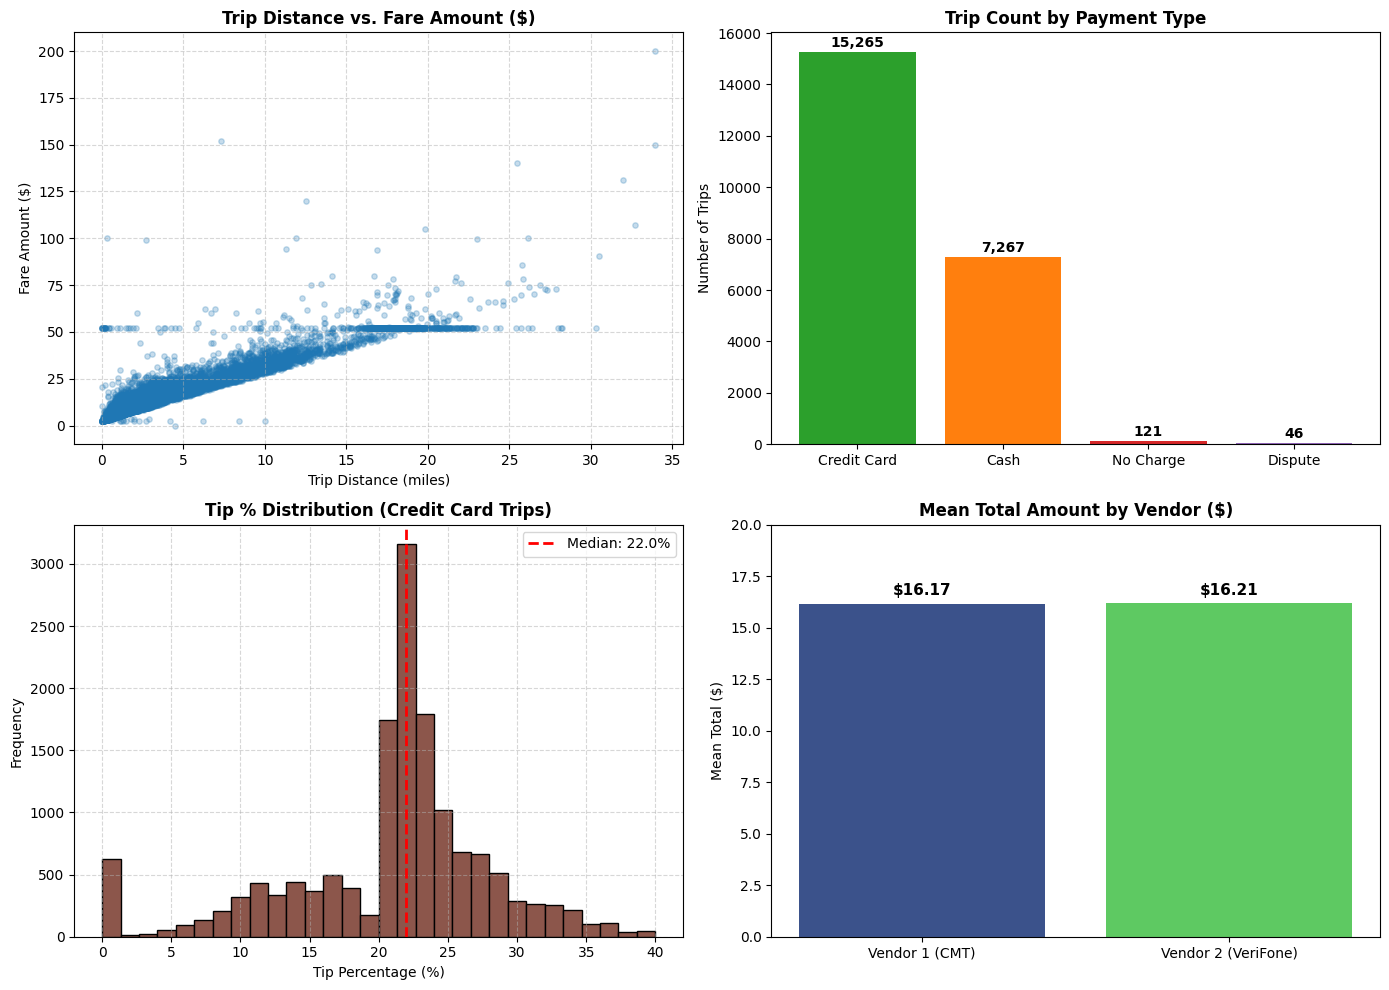

In [21]:
# Set up visualization canvas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Trip Distance vs. Fare Amount
axes[0, 0].scatter(clean_df['trip_distance'], clean_df['fare_amount'], alpha=0.25, color='#1f77b4', s=15)
axes[0, 0].set_title('Trip Distance vs. Fare Amount ($)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Trip Distance (miles)')
axes[0, 0].set_ylabel('Fare Amount ($)')
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

# 2. Trip Count by Payment Type
pay_labels = ['Credit Card', 'Cash', 'No Charge', 'Dispute']
pay_counts = t_data['payment_type'].value_counts().sort_index()
bars = axes[0, 1].bar(pay_labels, pay_counts.values, color=['#2ca02c', '#ff7f0e', '#d62728', '#9467bd'])
axes[0, 1].set_title('Trip Count by Payment Type', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Number of Trips')
for bar in bars:
    yval = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, yval + 200, f"{yval:,}", ha='center', fontweight='bold')

# 3. Tip % Distribution (Credit Card Trips)
cc_tips = clean_df['tip_percent'].dropna()
cc_tips_filtered = cc_tips[(cc_tips >= 0) & (cc_tips <= 40)]
axes[1, 0].hist(cc_tips_filtered, bins=30, color='#8c564b', edgecolor='black')
axes[1, 0].axvline(cc_tips.median(), color='red', linestyle='--', linewidth=2, label=f'Median: {cc_tips.median():.1f}%')
axes[1, 0].set_title('Tip % Distribution (Credit Card Trips)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Tip Percentage (%)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

# 4. Mean Total Amount by Vendor
vendor_means = clean_df.groupby('VendorID')['total_amount'].mean()
vendor_labels = ['Vendor 1 (CMT)', 'Vendor 2 (VeriFone)']
axes[1, 1].bar(vendor_labels, vendor_means.values, color=['#3b528b', '#5ec962'])
axes[1, 1].set_title('Mean Total Amount by Vendor ($)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Mean Total ($)')
axes[1, 1].set_ylim(0, 20)
for i, v in enumerate(vendor_means.values):
    axes[1, 1].text(i, v + 0.4, f"${v:.2f}", ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()